# Clustering Comparison: Fashion-MNIST

Comparing all 5 methods on Fashion-MNIST (`data/fashion-mnist_train.csv` +
`data/fashion-mnist_test.csv`, 70,000 28x28 grayscale clothing images, 10
classes as ground truth).

**Scale note:** Spectral Clustering and DBSCAN/HDBSCAN don't scale to 70k
points (O(n^2) or worse in time/memory). We take a **stratified subsample**
(~3,000 points, balanced across the 10 classes) after reducing pixels to 50
PCA components, so all 5 methods run in reasonable time and are directly
comparable. Results describe this subsample, not the full dataset.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sc4020 import data, clustering, metrics, viz, hyperparams

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
METRIC_COLS = [
    "method", "fit_seconds", "n_clusters_found", "noise_ratio",
    "silhouette", "davies_bouldin", "calinski_harabasz",
]
EXTERNAL_COLS = ["adjusted_rand_index", "normalized_mutual_info", "adjusted_mutual_info", "fowlkes_mallows"]


In [2]:
ds = data.load_fashion_mnist(n_samples=3000, n_pca=50, random_state=42)
print(f"{ds.name}: X={ds.X.shape}, classes={ds.class_names}, n_true_clusters={ds.n_true_clusters}")
print(f"PCA explained variance (50 components): {ds.extra['explained_variance_ratio'].sum():.3f}")

fashion_mnist: X=(3000, 50), classes=['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'], n_true_clusters=10
PCA explained variance (50 components): 0.865


## Exploratory look

In [3]:
labels, counts = np.unique(ds.y, return_counts=True)
pd.Series(counts, index=[ds.class_names[i] for i in labels], name="count").sort_values(ascending=False)

T-shirt/top    300
Trouser        300
Pullover       300
Dress          300
Coat           300
Sandal         300
Shirt          300
Sneaker        300
Bag            300
Ankle boot     300
Name: count, dtype: int64

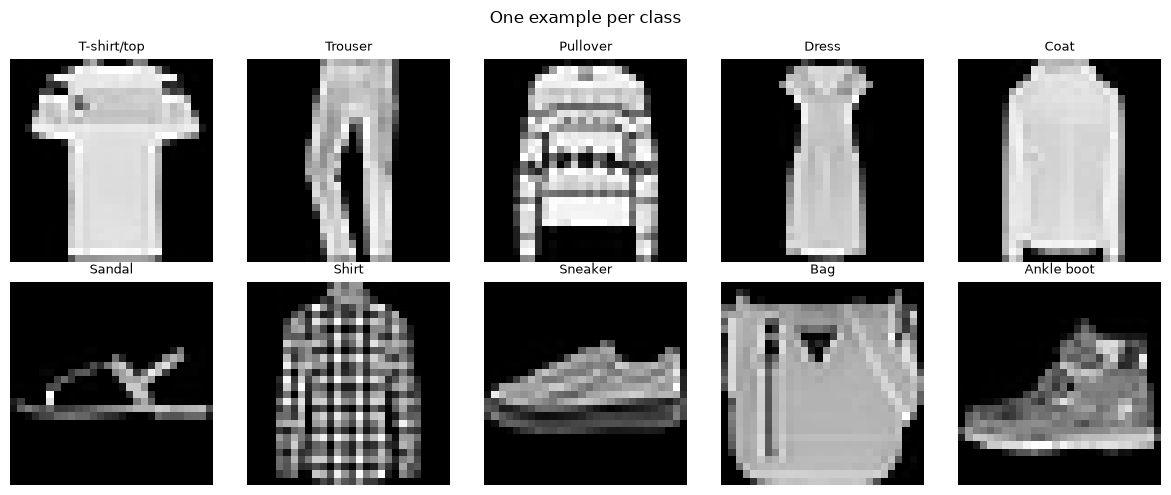

In [4]:
# A few example images per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls, ax in zip(range(10), axes.flat):
    idx = np.where(ds.y == cls)[0][0]
    ax.imshow(ds.extra["pixels"][idx].reshape(28, 28), cmap="gray")
    ax.set_title(ds.class_names[cls], fontsize=9)
    ax.axis("off")
fig.suptitle("One example per class")
plt.tight_layout()
plt.show()

## 2D embedding for visualization

Clustering runs on the 50-D PCA space; a further PCA to 2D here is only for
plotting.

In [5]:
from sklearn.decomposition import PCA
X_2d = PCA(n_components=2, random_state=42).fit_transform(ds.X)

## DBSCAN eps selection

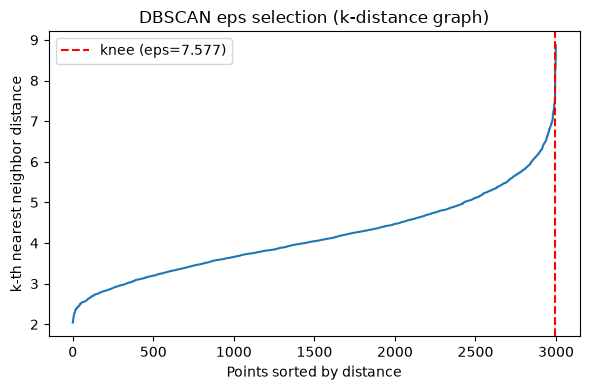

In [6]:
ms = hyperparams.default_min_samples(ds.X.shape[1])
kd = hyperparams.select_dbscan_eps(ds.X, min_samples=ms)
viz.plot_k_distance(kd.distances, kd.knee_idx, kd.eps_at_knee)
plt.show()

## Fit all 5 methods

K = 10 (true class count) for K-Means++ / GMM / Spectral Clustering.
Spectral Clustering uses a nearest-neighbors affinity (image-embedding
manifolds are typically not well captured by a single global RBF bandwidth).

In [7]:
results = clustering.run_all_methods(ds.X, ds.n_true_clusters, spectral_affinity="nearest_neighbors")
for name, r in results.items():
    print(f"{name:22s} params={r.params}  fit_seconds={r.fit_seconds:.3f}")

KMeans++               params={'n_clusters': 10}  fit_seconds=0.079
DBSCAN                 params={'eps': 3.7885727882385254, 'min_samples': 20}  fit_seconds=0.011
HDBSCAN                params={'min_cluster_size': 5}  fit_seconds=0.303
GMM                    params={'n_components': 10}  fit_seconds=2.799
Spectral Clustering    params={'n_clusters': 10, 'affinity': 'nearest_neighbors'}  fit_seconds=0.179


## Metrics

In [8]:
results_df = metrics.build_results_table(ds.name, ds.X, results, ds.y)
display(results_df[METRIC_COLS])
display(results_df[["method"] + EXTERNAL_COLS])

,method,fit_seconds,n_clusters_found,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,KMeans++,0.079439,10,0.000000,0.202065,1.470169,531.890855
1,DBSCAN,0.011124,2,0.331667,0.161152,1.181886,79.305788
2,HDBSCAN,0.303220,28,0.708667,0.228471,1.123200,125.893645
3,GMM,2.798608,10,0.000000,0.132121,2.036679,357.739297
4,Spectral Clustering,0.178743,10,0.000000,0.193616,1.567921,494.232337


,method,adjusted_rand_index,normalized_mutual_info,adjusted_mutual_info,fowlkes_mallows
0,KMeans++,0.343308,0.512117,0.509138,0.416696
1,DBSCAN,0.033155,0.100480,0.098648,0.268403
2,HDBSCAN,0.050307,0.330494,0.312532,0.283414
3,GMM,0.390900,0.564763,0.562097,0.461480
4,Spectral Clustering,0.398326,0.586044,0.583500,0.469193


## Cluster visualizations vs. ground truth

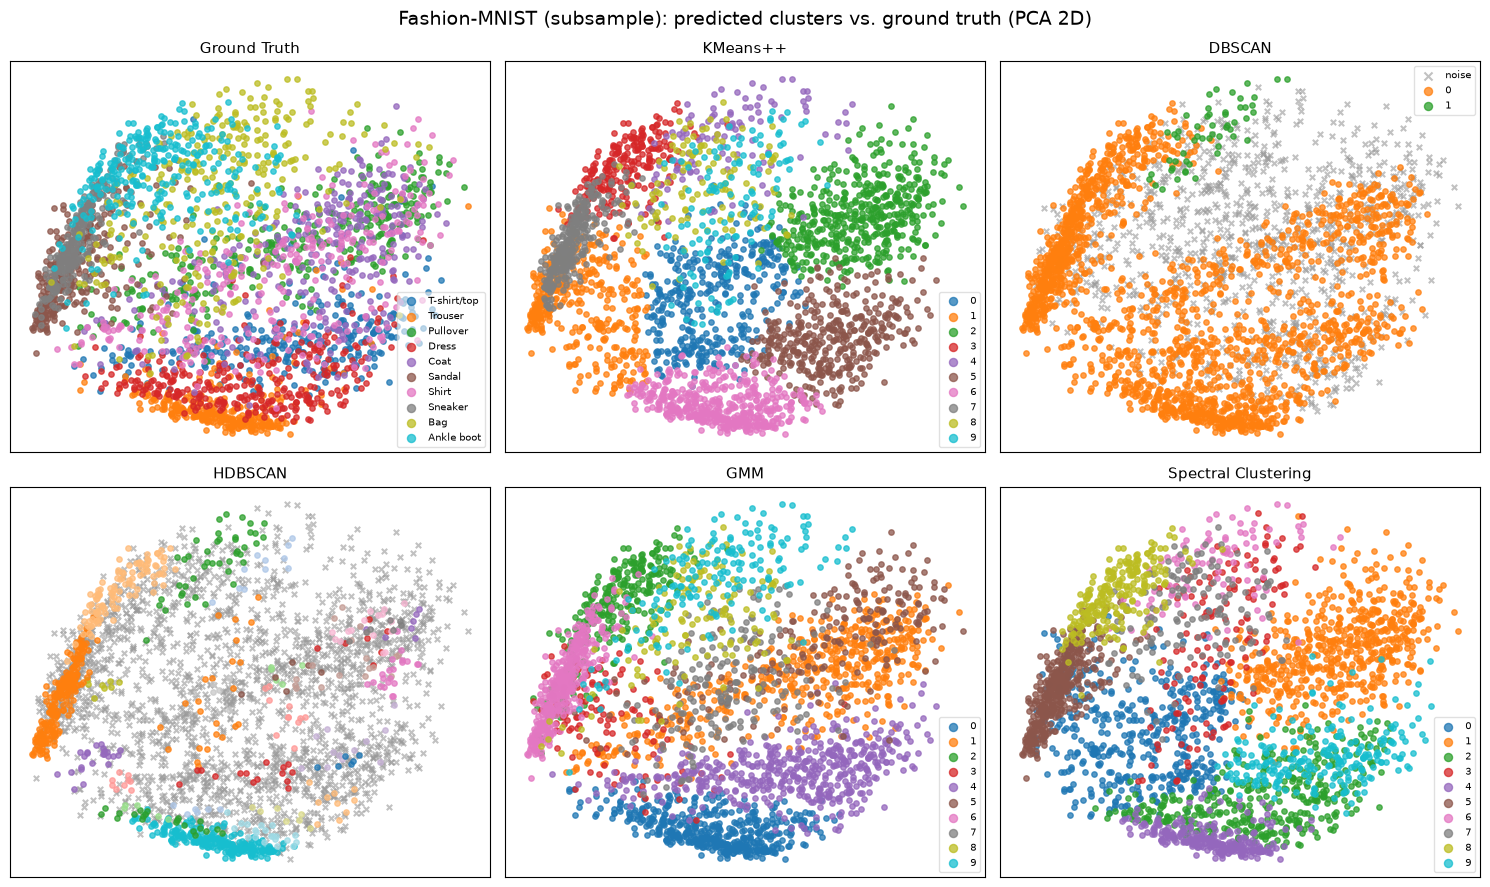

In [9]:
fig = viz.plot_cluster_grid(X_2d, results, y_true=ds.y, class_names=ds.class_names,
                             title="Fashion-MNIST (subsample): predicted clusters vs. ground truth (PCA 2D)")
plt.show()

## Qualitative check: example images per discovered cluster (K-Means++)

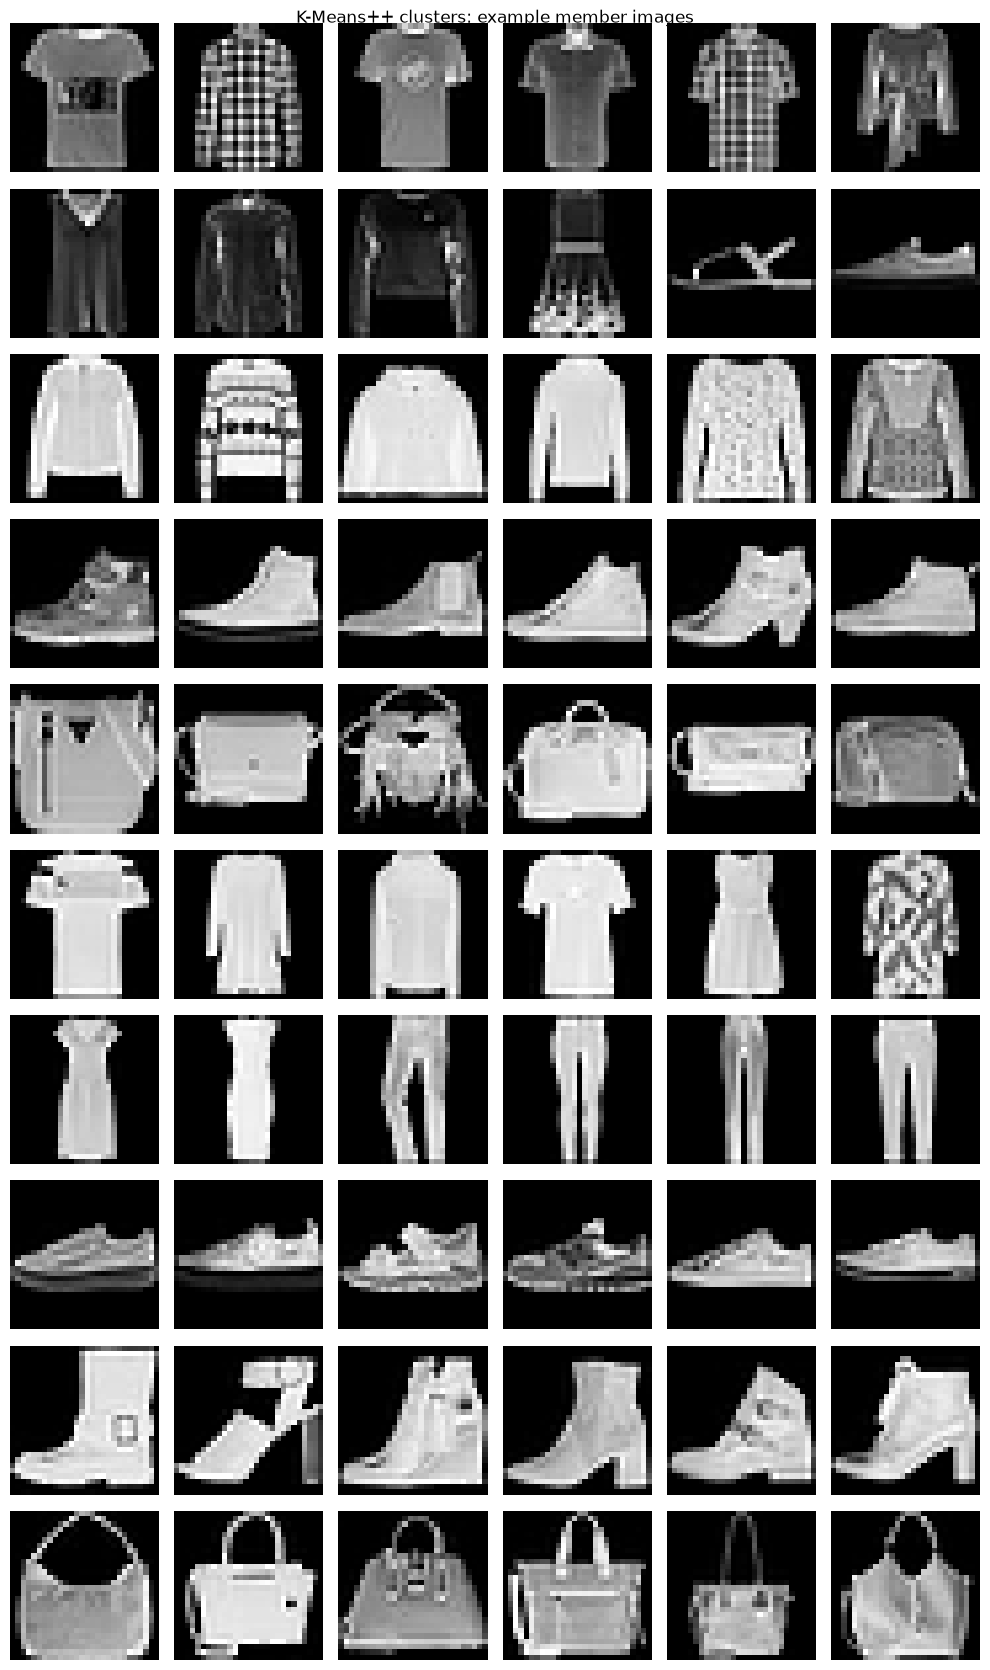

In [10]:
km_labels = results["KMeans++"].labels
fig, axes = plt.subplots(ds.n_true_clusters, 6, figsize=(10, 1.7 * ds.n_true_clusters))
for cluster_id in range(ds.n_true_clusters):
    idxs = np.where(km_labels == cluster_id)[0][:6]
    for col, ax in enumerate(axes[cluster_id]):
        if col < len(idxs):
            ax.imshow(ds.extra["pixels"][idxs[col]].reshape(28, 28), cmap="gray")
        ax.axis("off")
    axes[cluster_id, 0].set_ylabel(f"cluster {cluster_id}", rotation=0, labelpad=30, fontsize=8)
fig.suptitle("K-Means++ clusters: example member images")
plt.tight_layout()
plt.show()

## Discussion

- Even on a class-balanced subsample, Fashion-MNIST clustering is much harder
  than Wine/moons: visually similar classes (shirt/pullover/coat, sneaker/
  sandal/ankle-boot) overlap heavily in pixel/PCA space, so expect
  noticeably lower ARI/NMI across all methods than on the other datasets.
- **DBSCAN/HDBSCAN** often struggle here too (curse of dimensionality even
  at 50 PCA dims, plus uneven local density across visually-similar classes) —
  watch the `noise_ratio` and `n_clusters_found` columns to see whether they
  under- or over-segment relative to the true 10 classes.
- **Runtime** matters at this scale: compare `fit_seconds` across methods —
  Spectral Clustering's eigendecomposition and DBSCAN/HDBSCAN's neighbor
  search cost noticeably more than K-Means++/GMM even at just 3,000 points,
  which is exactly why the full 70k-point dataset was subsampled.
- Results here describe only the 3,000-point stratified subsample, not the
  full 70k-image dataset.